## Diabetes Prediction

In [88]:
#Let's start with importing necessary libraries
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [89]:
#read the data file
data = pd.read_csv(r"C:\Users\Sobiya Ayaz\OneDrive\Desktop\DiabetesPrediction_DecisionTreeClassifier\Dataset\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [90]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [91]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

We can see there few data for columns Glucose , Insulin, skin thickenss, BMI and Blood Pressure which have value as 0. That's not possible,right? you can do a quick search to see that one cannot have 0 values for these.
Let's deal with that. we can either remove such data or simply replace it with their respective mean values.
Let's do the latter.

In [92]:
#here few misconception is there lke BMI can not be zero, BP can't be zero, glucose, insuline can't be zero so lets try to fix it
# now replacing zero values with the mean of the column
data['BMI'] = data['BMI'].replace(0,data['BMI'].mean())
data['BloodPressure'] = data['BloodPressure'].replace(0,data['BloodPressure'].mean())
data['Glucose'] = data['Glucose'].replace(0,data['Glucose'].mean())
data['Insulin'] = data['Insulin'].replace(0,data['Insulin'].mean())
data['SkinThickness'] = data['SkinThickness'].replace(0,data['SkinThickness'].mean())



In [93]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

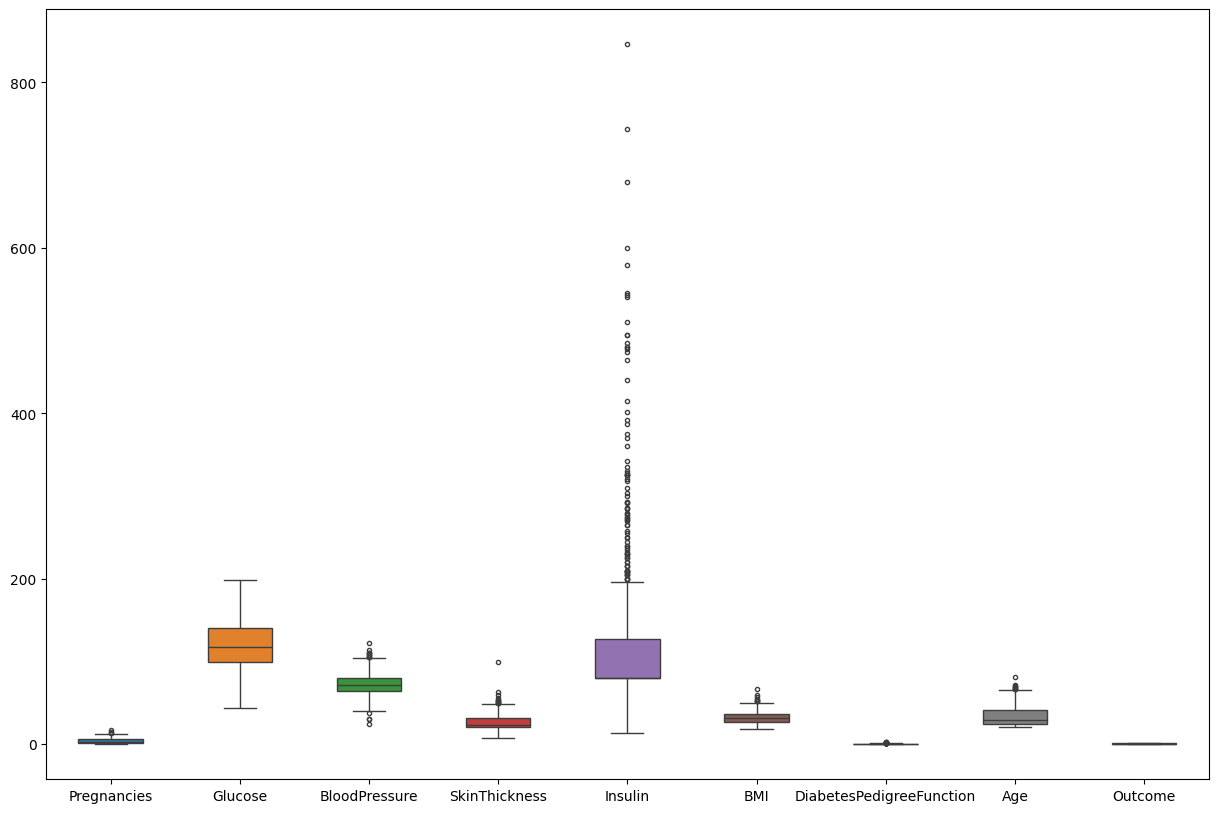

In [94]:
#now we have dealt with the 0 values and data looks better. But, there still are outliers present in some columns.lets visualize it
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(data=data, width= 0.5,ax=ax,  fliersize=3)

In [95]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1


In [96]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

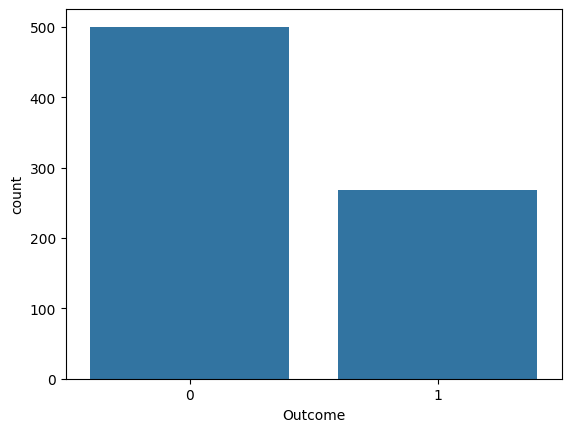

In [97]:
sns.countplot(x="Outcome", data=data)
plt.show()

In [98]:
#segregate the dependent and independent variable
X = data.drop(columns = ['Outcome'])
y = data['Outcome']

In [99]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [100]:
y_resampled.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Balance dataset
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81        99
           1       0.79      0.88      0.83       101

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [102]:
import os
import pickle

os.makedirs("../Model", exist_ok=True)

with open("../Model/modelForPrediction.pkl", "wb") as f:
    pickle.dump(model, f)

In [103]:
import pickle
##standard Scaling- Standardization
def scaler_standard(X_train, X_test):
    #scaling the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    #saving the model
    file = open('standardScalar.pkl','wb')
    pickle.dump(scaler,file)
    file.close()
    
    return X_train_scaled, X_test_scaled

In [104]:
X_train_scaled, X_test_scaled = scaler_standard(X_train, X_test)

In [105]:
print("\033[1mScaled training data:\033[0m\n ", X_train_scaled)
print("\033[1mScaled testing data:\033[0m\n", X_test_scaled)

Scaled training data:
  [[ 2.65454447e-01 -2.93482187e-01  1.55737274e+00 ...  1.75612230e-01
  -4.16373669e-01  3.43852224e-01]
 [-2.50565757e-02  1.97265590e-01 -3.39287267e-01 ... -5.21175997e-04
  -5.22031195e-01 -9.52073243e-01]
 [ 8.46476492e-01  5.24430775e-01  1.39168601e+00 ... -3.67465772e-01
  -1.04730004e+00  7.75827380e-01]
 ...
 [-6.06078621e-01  2.32383929e+00 -2.65181288e-01 ... -3.52787989e-01
  -9.56736446e-01  1.63977769e+00]
 [-1.18710067e+00  4.91714256e-01 -3.39287267e-01 ...  1.39386829e+00
  -8.14853482e-01 -4.33703056e-01]
 [-1.18710067e+00 -3.17500393e-02  1.88874620e+00 ... -1.52701070e+00
  -6.42782654e-01 -1.12486331e+00]]
Scaled testing data:
 [[-0.3155676  -0.06446656  0.56325236 ...  0.04351218 -0.51297484
  -0.69288815]
 [ 1.13698751 -1.99474115 -0.09949456 ... -0.13262123  0.37756717
   0.68943235]
 [ 2.00852058 -0.19533263  0.56325236 ...  1.37919051  0.93604266
   1.20780254]
 ...
 [-0.89658964 -0.98052908 -0.76224148 ...  0.04351218 -0.56127542
  -1

## Random Forest Classifier

In [106]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Support Vector Classifier

In [107]:
svc_clf=SVC()
svc_clf.fit(X_train_scaled,y_train)

## SVC prediction
y_pred_svc = svc_clf.predict(X_test_scaled)
print("Predicted values:\n", y_pred_svc)

accuracy = accuracy_score(y_test,y_pred_svc)
print("Accuracy:", accuracy)

Predicted values:
 [0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0
 1 1 0 0 0 1 1 0 0 1 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0
 1 0 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0
 1 1 1 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 1 1 0 1 1]
Accuracy: 0.805


In [108]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt_clf = dt_clf.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred_dt_clf)
conf_mat
conf_mat

array([[73, 26],
       [ 8, 93]])

In [109]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt_clf))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81        99
           1       0.78      0.92      0.85       101

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



In [110]:
import os
import pickle

os.makedirs("Model", exist_ok=True)

with open("Model/modelForPrediction.pkl", "wb") as f:
    pickle.dump(dt_clf, f)

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import RandomOverSampler

# features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# balance dataset
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

# full report
print(classification_report(y_test, y_pred))

Accuracy: 84.0
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        99
           1       0.81      0.90      0.85       101

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200

